# Análise de custos com Café BPS - 2024 X 2025

### Importação de base e Tratamento de dados:

In [124]:
import pandas as pd

base_cafe_2024 = pd.read_excel("base_cafe_bps_2024.xlsx")
base_cafe_2025 = pd.read_excel("base_cafe_bps_2025.xlsx")

display(base_cafe_2024)
display(base_cafe_2025)

,Cód. Item,Item,Unidade,Qtde.,Custo 2024
0,1130,CAIXA DRIP COFFEE SCADA COM 10 SACHES,CX,3.0000,88.500000
1,6,CAPPUCCINO DIET,KG,4.1300,NaN
2,2,CAPPUCCINO SCADA - 1KG,KG,189.0270,NaN
3,436,CHA MATE SOLUVEL,KG,0.0710,NaN
4,1059,CHA MATE TOSTADO,KG,27.9822,NaN
5,107,CHA QUENTE NACIONAL SACHE,UN,920.0000,NaN
6,441,"CHOCOLATE CREMOSO- 1,05KG",KG,78.1635,NaN
7,12,OVOMALTINE,KG,3.1850,NaN
8,1166,SACHE AVULSO DRIP COFFEE,UN,6.0000,0.000000
9,725,SCADA B.AMARELO=CITRIC0 GRAO 250GR,KG,26.1400,2073.600000


,Cód. Item,Item,Unidade,Qtde.,Custo 2025
0,1130,CAIXA DRIP COFFEE SCADA COM 10 SACHES,CX,1.0000,0.0
1,6,CAPPUCCINO DIET,KG,2.1560,NaN
2,2,CAPPUCCINO SCADA - 1KG,KG,208.1400,NaN
3,436,CHA MATE SOLUVEL,KG,0.0100,NaN
4,1059,CHA MATE TOSTADO,KG,10.7734,NaN
5,107,CHA QUENTE NACIONAL SACHE,UN,885.0000,NaN
6,441,"CHOCOLATE CREMOSO- 1,05KG",KG,71.3350,NaN
7,823,GARRAFA 20 ANOS SCADA,UN,10.0000,0.0
8,12,OVOMALTINE,KG,1.1900,NaN
9,725,SCADA B.AMARELO=CITRIC0 GRAO 250GR,KG,31.2650,3564.0


In [125]:
# Exclusão de itens irrelevantes:
base_cafe_2024 = base_cafe_2024[~base_cafe_2024["Item"].str.contains("CAPPUCCINO", case=False, na=False)]
base_cafe_2024 = base_cafe_2024[~base_cafe_2024["Item"].str.contains("CHA", case=False, na=False)]
base_cafe_2024 = base_cafe_2024[~base_cafe_2024["Item"].str.contains("CHOCOLATE", case=False, na=False)]
base_cafe_2024 = base_cafe_2024[~base_cafe_2024["Item"].str.contains("OVOMALTINE", case=False, na=False)]
base_cafe_2024 = base_cafe_2024.rename(columns={'Qtde.': 'Qtde vendida 2024'}) # Renomear uma coluna

base_cafe_2025 = base_cafe_2025[~base_cafe_2025["Item"].str.contains("CAPPUCCINO", case=False, na=False)]
base_cafe_2025 = base_cafe_2025[~base_cafe_2025["Item"].str.contains("CHA", case=False, na=False)]
base_cafe_2025 = base_cafe_2025[~base_cafe_2025["Item"].str.contains("CHOCOLATE", case=False, na=False)]
base_cafe_2025 = base_cafe_2025[~base_cafe_2025["Item"].str.contains("OVOMALTINE", case=False, na=False)]
base_cafe_2025 = base_cafe_2025.rename(columns={'Qtde.': 'Qtde vendida 2025'}) # Renomear uma coluna

display(base_cafe_2024)
display(base_cafe_2025)

,Cód. Item,Item,Unidade,Qtde vendida 2024,Custo 2024
0,1130,CAIXA DRIP COFFEE SCADA COM 10 SACHES,CX,3.0000,88.500000
8,1166,SACHE AVULSO DRIP COFFEE,UN,6.0000,0.000000
9,725,SCADA B.AMARELO=CITRIC0 GRAO 250GR,KG,26.1400,2073.600000
10,723,SCADA B.VERMELHO=FRUTADO GRAO 250GR,KG,62.2600,6640.000000
11,1149,SCADA BLEND GRAO 1 KG,KG,460.6658,39416.300000
12,662,SCADA BLEND GRAO 250G,KG,36.0350,4933.333333
13,722,SCADA DESCAFEINADO GRAO 250G,KG,10.4950,2064.000000
14,930,SCADA EDICAO ESPECIAL GRAO 250G,KG,7.2500,2268.000000
15,724,SCADA ORGANICO GRAO 250G,KG,4.7700,883.200000
16,546,UNIQUE EDICAO ESPECIAL GRAO 250G,KG,13.3750,2597.000000


,Cód. Item,Item,Unidade,Qtde vendida 2025,Custo 2025
0,1130,CAIXA DRIP COFFEE SCADA COM 10 SACHES,CX,1.0000,0.0
7,823,GARRAFA 20 ANOS SCADA,UN,10.0000,0.0
9,725,SCADA B.AMARELO=CITRIC0 GRAO 250GR,KG,31.2650,3564.0
10,723,SCADA B.VERMELHO=FRUTADO GRAO 250GR,KG,88.3900,9288.0
11,1149,SCADA BLEND GRAO 1 KG,KG,428.1512,44649.0
12,662,SCADA BLEND GRAO 250G,KG,61.8300,8478.0
13,722,SCADA DESCAFEINADO GRAO 250G,KG,5.6700,1692.0
14,1298,SCADA ED. 20 ANOS - RARIDADE,KG,1.0800,0.0
15,930,SCADA EDICAO ESPECIAL GRAO 250G,KG,9.3550,1320.0
16,724,SCADA ORGANICO GRAO 250G,KG,4.9150,540.0


In [126]:
# Agrupamento de bases:
comparativo_df = pd.merge(
    base_cafe_2024[['Item', 'Unidade', 'Qtde vendida 2024', 'Custo 2024']], 
    base_cafe_2025[['Item', 'Qtde vendida 2025', 'Custo 2025']], 
    on='Item', how='outer'
    )
comparativo_df = comparativo_df.fillna(0) # Substituir valores NaN por 0
# Inserir novas colunas de análise:
comparativo_df["Dif Qtd 24/25"] = comparativo_df["Qtde vendida 2025"] - comparativo_df["Qtde vendida 2024"]
comparativo_df["Dif Custo 24/25"] = comparativo_df["Custo 2025"] - comparativo_df["Custo 2024"]
comparativo_df["R$/Kg 2024"] = comparativo_df['Custo 2024'] / comparativo_df['Qtde vendida 2024'].replace({0: 1}) # Evitar divisão por zero
comparativo_df["R$/Kg 2025"] = comparativo_df['Custo 2025'] / comparativo_df['Qtde vendida 2025'].replace({0: 1}) # Evitar divisão por zero
comparativo_df["Dif R$/Kg 24/25"] = comparativo_df["R$/Kg 2025"] - comparativo_df["R$/Kg 2024"]

# Formatação de colunas monetárias:
comparativo_df["Dif Qtd 24/25"] = comparativo_df["Dif Qtd 24/25"].round(2)
comparativo_df["Dif Custo 24/25"] = comparativo_df["Dif Custo 24/25"].round(2)
comparativo_df["R$/Kg 2024"] = comparativo_df["R$/Kg 2024"].round(2)
comparativo_df["R$/Kg 2025"] = comparativo_df["R$/Kg 2025"].round(2)
comparativo_df["Dif R$/Kg 24/25"] = comparativo_df["Dif R$/Kg 24/25"].round(2)
comparativo_df["Qtde vendida 2024"] = comparativo_df["Qtde vendida 2024"].round(2)
comparativo_df["Qtde vendida 2025"] = comparativo_df["Qtde vendida 2025"].round(2)
comparativo_df["Custo 2024"] = comparativo_df["Custo 2024"].round(2)
comparativo_df["Custo 2025"] = comparativo_df["Custo 2025"].round(2)

def ajuste_unidade(row): #Corrigindo unidade de medida
    item = str(row["Item"]).lower()
    if 'garrafa 20' in item:
        return 'UN'
    elif '20 anos' in item:
        return 'KG'
    else:
        return row['Unidade']

comparativo_df['Unidade'] = comparativo_df.apply(ajuste_unidade, axis=1)

display(comparativo_df)

,Item,Unidade,Qtde vendida 2024,Custo 2024,Qtde vendida 2025,Custo 2025,Dif Qtd 24/25,Dif Custo 24/25,R$/Kg 2024,R$/Kg 2025,Dif R$/Kg 24/25
0,CAIXA DRIP COFFEE SCADA COM 10 SACHES,CX,3.00,88.50,1.00,0.0,-2.00,-88.50,29.50,0.00,-29.50
1,GARRAFA 20 ANOS SCADA,UN,0.00,0.00,10.00,0.0,10.00,0.00,0.00,0.00,0.00
2,SACHE AVULSO DRIP COFFEE,UN,6.00,0.00,0.00,0.0,-6.00,0.00,0.00,0.00,0.00
3,SCADA B.AMARELO=CITRIC0 GRAO 250GR,KG,26.14,2073.60,31.26,3564.0,5.12,1490.40,79.33,113.99,34.67
4,SCADA B.VERMELHO=FRUTADO GRAO 250GR,KG,62.26,6640.00,88.39,9288.0,26.13,2648.00,106.65,105.08,-1.57
5,SCADA BLEND GRAO 1 KG,KG,460.67,39416.30,428.15,44649.0,-32.51,5232.70,85.56,104.28,18.72
6,SCADA BLEND GRAO 250G,KG,36.03,4933.33,61.83,8478.0,25.80,3544.67,136.90,137.12,0.21
7,SCADA DESCAFEINADO GRAO 250G,KG,10.50,2064.00,5.67,1692.0,-4.82,-372.00,196.67,298.41,101.75
8,SCADA ED. 20 ANOS - RARIDADE,KG,0.00,0.00,1.08,0.0,1.08,0.00,0.00,0.00,0.00
9,SCADA EDICAO ESPECIAL GRAO 250G,KG,7.25,2268.00,9.36,1320.0,2.11,-948.00,312.83,141.10,-171.73


### Análises Globais

In [127]:
total_kg_2024 = comparativo_df['Qtde vendida 2024'].sum()
total_kg_2025 = comparativo_df['Qtde vendida 2025'].sum()
total_custo_2024 = comparativo_df['Custo 2024'].sum()
total_custo_2025 = comparativo_df['Custo 2025'].sum()
custo_por_kg_2024 = total_custo_2024 / total_kg_2024 if total_kg_2024 != 0 else 0
custo_por_kg_2025 = total_custo_2025 / total_kg_2025 if total_kg_2025 != 0 else 0

print(f'Total kg vendido em 2024: {total_kg_2024:.2f} kg')
print(f'Total kg vendido em 2025: {total_kg_2025:.2f} kg')
print('Diferença kg vendido 24/25: {:.2f} kg'.format(total_kg_2025 - total_kg_2024))
print("- - - - - - - - - - - - - - - - - - - - - -")
print(f'Total custo em 2024: R$ {total_custo_2024:,.2f}')
print(f'Total custo em 2025: R$ {total_custo_2025:,.2f}')
print('Diferença custo 24/25: R$ {:,.2f}'.format(total_custo_2025 - total_custo_2024))
print("- - - - - - - - - - - - - - - - - - - - - -")
print(f'Custo por kg em 2024: R$ {custo_por_kg_2024:,.2f}')
print(f'Custo por kg em 2025: R$ {custo_por_kg_2025:,.2f}')
print('Diferença custo por kg 24/25: R$ {:,.2f}'.format(custo_por_kg_2025 - custo_por_kg_2024))

Total kg vendido em 2024: 634.34 kg
Total kg vendido em 2025: 653.80 kg
Diferença kg vendido 24/25: 19.46 kg
- - - - - - - - - - - - - - - - - - - - - -
Total custo em 2024: R$ 64,424.73
Total custo em 2025: R$ 71,141.00
Diferença custo 24/25: R$ 6,716.27
- - - - - - - - - - - - - - - - - - - - - -
Custo por kg em 2024: R$ 101.56
Custo por kg em 2025: R$ 108.81
Diferença custo por kg 24/25: R$ 7.25


In [ ]:
# Exportar base para Excel:
#comparativo_df.to_excel("comparativo_cafe_bps.xlsx", index=False)

# Gráficos:

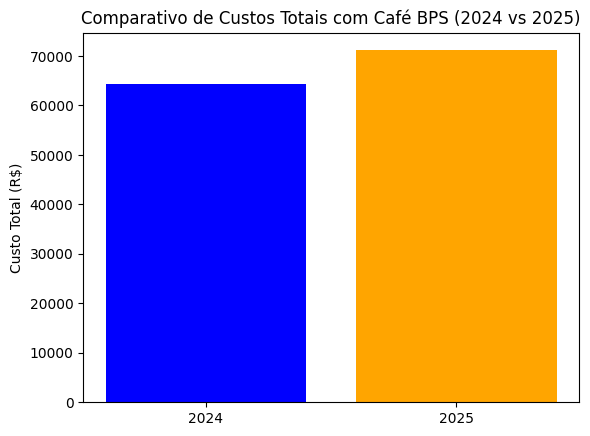

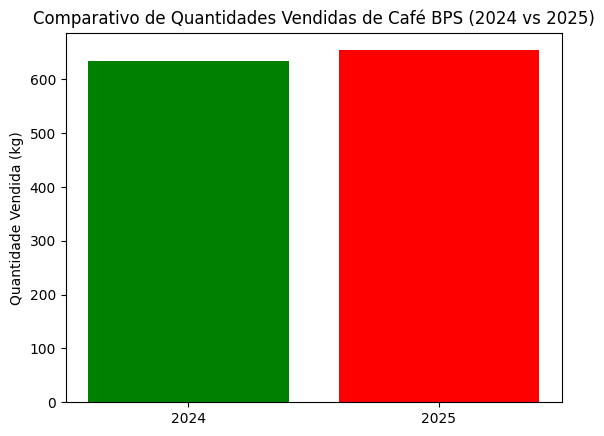

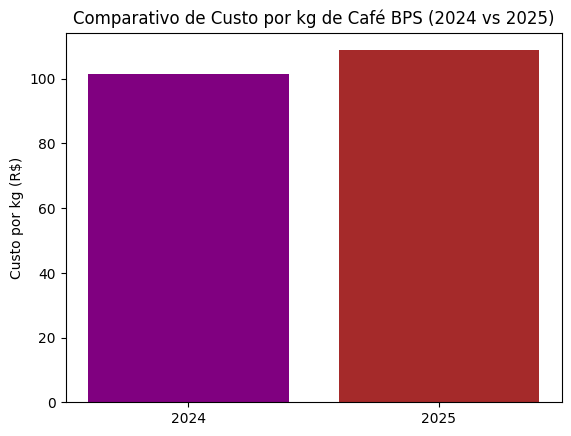

In [129]:
import matplotlib.pyplot as plt
# Gráfico de barras comparativo de custos totais
anos = ['2024', '2025']
custos = [total_custo_2024, total_custo_2025]
x = range(len(anos))
plt.bar(x, custos, color=['blue', 'orange'])
plt.xticks(x, anos)
plt.ylabel('Custo Total (R$)')
plt.title('Comparativo de Custos Totais com Café BPS (2024 vs 2025)')
plt.show()
# Gráfico de barras comparativo de quantidades vendidas
quantidade = [total_kg_2024, total_kg_2025]
plt.bar(x, quantidade, color=['green', 'red'])
plt.xticks(x, anos)
plt.ylabel('Quantidade Vendida (kg)')
plt.title('Comparativo de Quantidades Vendidas de Café BPS (2024 vs 2025)')
plt.show()
# Gráfico de barras comparativo de custo por kg
custo_por_kg = [custo_por_kg_2024, custo_por_kg_2025]
plt.bar(x, custo_por_kg, color=['purple', 'brown'])
plt.xticks(x, anos)
plt.ylabel('Custo por kg (R$)')
plt.title('Comparativo de Custo por kg de Café BPS (2024 vs 2025)')
plt.show()